## Middleware

Middleware provides a way to more tightly control what happens inside agent. Middleware is useful for the following:

- Tracking agent behaviour with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [9]:
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()
root = Path.cwd()
if not (root / ".env").exists() and root.parent.exists():
    root = root.parent

env_path = root / ".env"
load_dotenv(env_path, override=True)

key = os.getenv("GROQ_API_KEY") or os.getenv("groq")


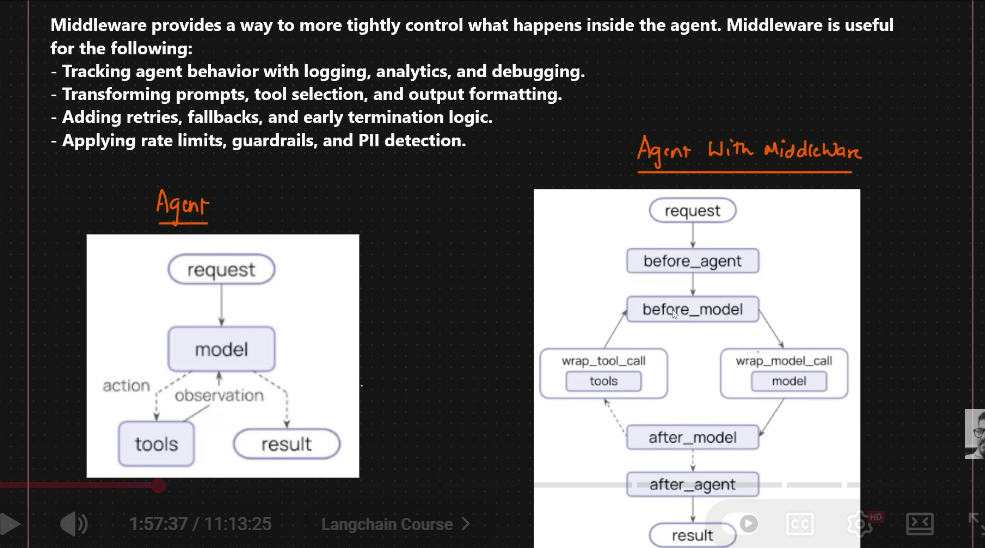

built in middleware - https://docs.langchain.com/oss/python/langchain/middleware/built-in#tool-error-full-example

### Summarization middleware


In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    checkpointer=InMemorySaver(),
    middleware=[SummarizationMiddleware(model="groq:openai/gpt-oss-20b",trigger=("messages",3),keep=("messages",2))]

)

In [11]:
### Run with thread id
from langchain_core.runnables import RunnableConfig

config: RunnableConfig = {
    "configurable": {
        "thread_id": "test-1"
    }
}

In [12]:
questions = [
    "what is 2+2?",
    "what is 10+5",
    "what is a car",
    "what is 10-29",
    "what is 99-2",
    "where is earth"
]
for q in questions:
    response=agent.invoke(
        {"messages": [HumanMessage(content=q)]},
        config=config
    )
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='what is 2+2?', additional_kwargs={}, response_metadata={}, id='a7ffb428-b86e-4acb-9b04-908c3e19fd3e'), AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'The user asks: "what is 2+2?" The answer is 4. It\'s a straightforward math question. We should answer simply.'}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 78, 'total_tokens': 127, 'completion_time': 0.066112307, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.004340478, 'prompt_tokens_details': None, 'queue_time': 1.006901277, 'total_time': 0.070452785}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e2cb7a84ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0c4bf-add7-7c73-8da5-d313f45a4732-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 49, 'total_tokens': 127

## Based on token size

In [13]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - return long response to use more tokens"""
    return f"""Hotels in {city}:
    1 grand hotel: 5 star,$ 33432/night, spa, pool,gym
    2. City Inn - 4 star $ 9832/night, business center
    3. Budget Stay - 3 star , $75/night, free wifi"""

agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-20b",
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ]
)
config={"configurable":{"thread_id":"test-1"}}

def count_token(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars//4

In [14]:
cities=["paris","Delhi", "London","New York", "Tokyo", "Dubai"]

for city in cities:
    response=agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    tokens = count_token(response["messages"])
    print(f"{city}: {tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

paris: 224 tokens, 4 messages
[HumanMessage(content='Find hotels in paris', additional_kwargs={}, response_metadata={}, id='074d0c25-4a24-4b75-b313-af759e96083c'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Find hotels in paris". We have a function "search_hotels" that takes a city string. We should call that function with city "Paris". Then we should return the response. We should not add any additional text, just the function call.', 'tool_calls': [{'id': 'fc_4cb8989f-ad19-4070-b6d8-3a8f325921b7', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 129, 'total_tokens': 209, 'completion_time': 0.087440661, 'completion_tokens_details': {'reasoning_tokens': 56}, 'prompt_time': 0.046570285, 'prompt_tokens_details': None, 'queue_time': 0.326446689, 'total_time': 0.134010946}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'f

## Fraction

In [15]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """search hotel"""
    return f"Hotels in {city}: Grand Hotel Rs 30000, city inn rs 5444"

agent =create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-20b",
            trigger = ("fraction", 0.005), #0.5% = ~ 640 tokens
            keep = ("fraction",0.002), #0.2%

        ),
    ],
)

config = {"configurable":{"thread_id":"test- 34"}}

def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) //4

cities=["paris","Delhi", "London","New York", "Tokyo", "Dubai"]

for city in cities:
    response=agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    tokens = count_token(response["messages"])
    #fractions = tokens/ model token limit
    print(f"{city}: {tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")


paris: 78 tokens, 4 messages
[HumanMessage(content='Find hotels in paris', additional_kwargs={}, response_metadata={}, id='a3468027-e8d4-401c-a5bf-328e282feee8'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to use the function to search hotels in Paris. The function is search_hotels with a city parameter. We need to call it.', 'tool_calls': [{'id': 'fc_a03ba566-a8c1-426d-a90b-69ba488958cb', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 121, 'total_tokens': 175, 'completion_time': 0.054200513, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.005841244, 'prompt_tokens_details': None, 'queue_time': 0.314873291, 'total_time': 0.060041757}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, 

## Human In The Loop Middleware

Pause agent execution for human approval, editing or rejection of tool calls before they execute. Human in the loop is useful for the following:
- High - stakes operations requiring human approval (eg database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long -running conversations where human feedback guides the agent.

In [16]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """reads email by its id"""
    return f"Email content for ID: {email_id} \n You are Selected"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Function to send email"""
    return f"Email sent to {recipient} with subject {subject}"


In [17]:
agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools = [read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
)

In [18]:
config = {"configurable":{"thread_id":"test-approve"}}
result = agent.invoke(
    {"messages":[HumanMessage(content="Send email to john@test.com with subject 'hello' and body 'How are you?")]},
    config=config
)

In [19]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'hello' and body 'How are you?", additional_kwargs={}, response_metadata={}, id='04ef001b-a13b-46a5-940e-9476a8c26ee6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to call send_email_tool with body 'How are you?', recipient 'john@test.com', subject 'hello'.", 'tool_calls': [{'id': 'fc_4af1aa4e-855e-4722-b576-571317975ba6', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 168, 'total_tokens': 230, 'completion_time': 0.072700081, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.009758476, 'prompt_tokens_details': None, 'queue_time': 0.309173002, 'total_time': 0.082458557}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_24bfb4a850', 'service_tier': 'on_demand', 'finish_re

In [20]:
from langgraph.types import Command
if "__interrupt__" in result:
    print("Paused! Approving...........")

    result = agent.invoke(
        Command(
            resume = {
                "decisions":[
                    {"type":"approve"}
                ]
            }
        ),
        config=config
    )
    print(f"Result: {result['messages'][-1].content}")

Paused! Approving...........
Result: ✅ Email sent to john@test.com with subject “hello”. Let me know if you need anything else!


In [21]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'hello' and body 'How are you?", additional_kwargs={}, response_metadata={}, id='04ef001b-a13b-46a5-940e-9476a8c26ee6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to call send_email_tool with body 'How are you?', recipient 'john@test.com', subject 'hello'.", 'tool_calls': [{'id': 'fc_4af1aa4e-855e-4722-b576-571317975ba6', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 168, 'total_tokens': 230, 'completion_time': 0.072700081, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.009758476, 'prompt_tokens_details': None, 'queue_time': 0.309173002, 'total_time': 0.082458557}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_24bfb4a850', 'service_tier': 'on_demand', 'finish_re

## EDIT

In [67]:
agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    tools = [read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    system_prompt=(
        "When a human edits a tool call, treat the edited arguments as final and authoritative. "
        "Do not retry the original tool call or send another email after the edited call succeeds."
    ),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
)

In [68]:
config = {"configurable":{"thread_id":"test-approve14"}}
result = agent.invoke(
    {"messages":[HumanMessage(content="Send email to john@test.com with subject 'hello' and body 'How are you?")]},
    config=config
)

In [69]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'hello' and body 'How are you?", additional_kwargs={}, response_metadata={}, id='0458b5a6-e570-4f62-b9bd-9d36d4d67695'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email. Use send_email_tool.', 'tool_calls': [{'id': 'fc_60b15502-fecc-4a92-9ca6-4a31010428bb', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 205, 'total_tokens': 263, 'completion_time': 0.12183624, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.008338306, 'prompt_tokens_details': None, 'queue_time': 0.317569791, 'total_time': 0.130174546}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_96d96a151c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': '

In [70]:
from langgraph.types import Command
if "__interrupt__" in result:
    print("Paused! Editing...........")

    result = agent.invoke(
        Command(
            resume = {
                "decisions":[
                    {"type":"edit",
                     "edited_action":{
                         "name":"send_email_tool",
                         "args":{
                             "recipient": "max@gmail.com",
                             "subject": "leave application",
                             "body":"I want leave"
                         }
                     }
                     }
                ]
            }
        ),
        config=config
    )
    print(f"Result: {result['messages'][-1].content}")

Paused! Editing...........
Result: 


In [71]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'hello' and body 'How are you?", additional_kwargs={}, response_metadata={}, id='0458b5a6-e570-4f62-b9bd-9d36d4d67695'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email. Use send_email_tool.', 'tool_calls': [{'id': 'fc_60b15502-fecc-4a92-9ca6-4a31010428bb', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 205, 'total_tokens': 263, 'completion_time': 0.12183624, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.008338306, 'prompt_tokens_details': None, 'queue_time': 0.317569791, 'total_time': 0.130174546}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_96d96a151c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': '